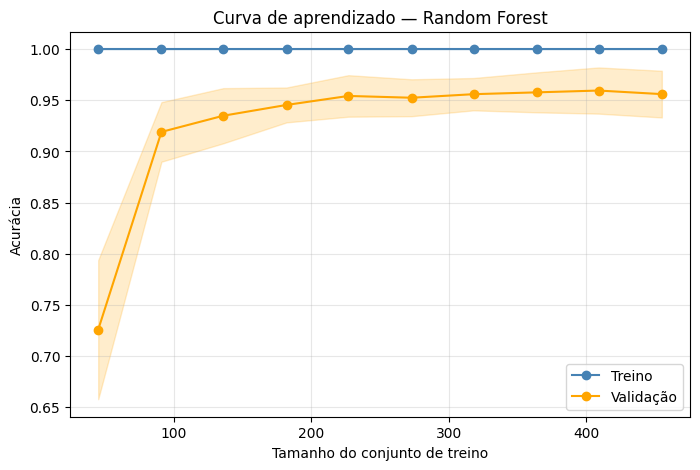

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

X, y = load_breast_cancer(return_X_y=True)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=modelo,
    X=X, y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),   # 10 frações entre 10% e 100%
    cv=5,                                     # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Cada elemento de train_scores tem shape (n_sizes, n_folds): tiramos média e desvio
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Treino', color='steelblue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', label='Validação', color='orange')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='orange')

plt.xlabel('Tamanho do conjunto de treino')
plt.ylabel('Acurácia')
plt.title('Curva de aprendizado — Random Forest')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

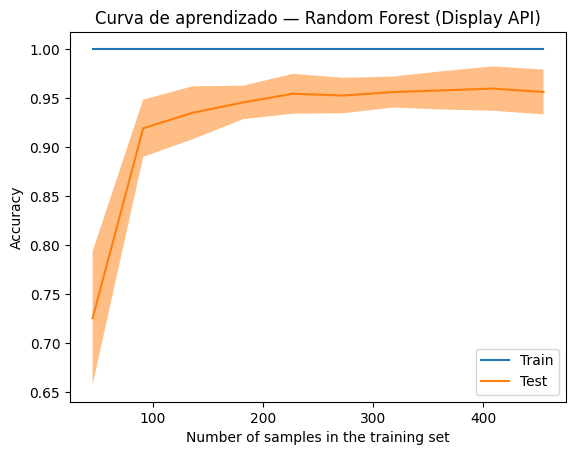

In [2]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    modelo, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)
plt.title('Curva de aprendizado — Random Forest (Display API)')
plt.show()